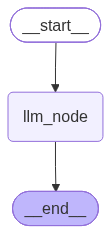

2026-08-03 08:35:14.710 | INFO     | __main__:llm_node:47 - 当前用户:Alice,会员等级:VIP


{'messages': [], 'user_input': '你好，帮我查一下最近有什么优惠活动', 'output': '亲爱的Alice，感谢您的咨询！让我为您查一下最新的VIP专属优惠活动，请稍等片刻。稍后我会把详细信息发给您，如果有特别偏好，也请随时告诉哦~ VIP🏅服务'}


In [3]:
from dataclasses import dataclass

from IPython.display import display
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import MessagesState, StateGraph
from langgraph.runtime import Runtime
from loguru import logger

load_dotenv(override=True)

# 获取大模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":
            {
                "type": "disabled"
            }
    }
)


# 1、定义运行时的环境上下文
@dataclass
class UserContext:
    username: str
    membership_level: str


# 2、定义状态
class OverAllState(MessagesState):
    user_input: str
    output: str


# 3、定义节点
def llm_node(state: OverAllState, runtime: Runtime[UserContext]) -> OverAllState:
    # 1、获取环境上下文 判断当前用户的等级
    runtime_context = runtime.context
    # 处理系统提示词
    if runtime_context:
        level = runtime_context.membership_level
        username = runtime_context.username
        logger.info(f"当前用户:{username},会员等级:{level}")

        if level == "VIP":
            system_prompt = f"你是高级客户助力,当前的VIP用户是{username},请使用尊称'您‘,语气热情周到,回复末尾加上'VIP🏅服务'"
        else:
            system_prompt = f"你是普通客户助理,当前用户是{username},请友好简洁回复问题"
    else:
        system_prompt = f"你是普通客户助理,请友好简洁回复问题"

    user_input = state["user_input"]
    messages = state.get("messages", [])
    response = model.invoke(
        [SystemMessage(content=system_prompt)] + messages + [HumanMessage(content=user_input)]).content
    return {
        "messages": messages,
        "output": response
    }


# 4、构建图
builder = StateGraph(state_schema=OverAllState, context_schema=UserContext)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

graph = builder.compile()

display(graph)

# ============第一次调用：传入VIP上下文用户 =============
res = graph.invoke({"user_input": "你好，帮我查一下最近有什么优惠活动"},
                   context=UserContext(username="Alice", membership_level="VIP"))

print(res)

In [4]:
# ============第二次调用：传入普通上下文用户 =============
res = graph.invoke({"user_input": "你好，帮我查一下最近有什么优惠活动"},
                   context=UserContext(username="Alice", membership_level="普通用户"))

print(res)

2026-08-03 08:36:20.361 | INFO     | __main__:llm_node:47 - 当前用户:Alice,会员等级:普通用户


{'messages': [], 'user_input': '你好，帮我查一下最近有什么优惠活动', 'output': '您好Alice！请问您想了解哪方面的优惠呢？比如理财产品、银行卡消费优惠，还是贷款活动？告诉我您的需求，我马上为您查询相关信息！😊'}
